# Week 3 Day 4: Outlier Detection Basics
Use box plots and the IQR method to detect outliers.

Q1: $53,988.27 | Q3: $65,049.91 | IQR: $11,061.63
Lower Bound: $37,395.82 | Upper Bound: $81,642.36

Detected 4 Outliers:
            Salary
74    33802.548959
100  250000.000000
101  300000.000000
102   15000.000000


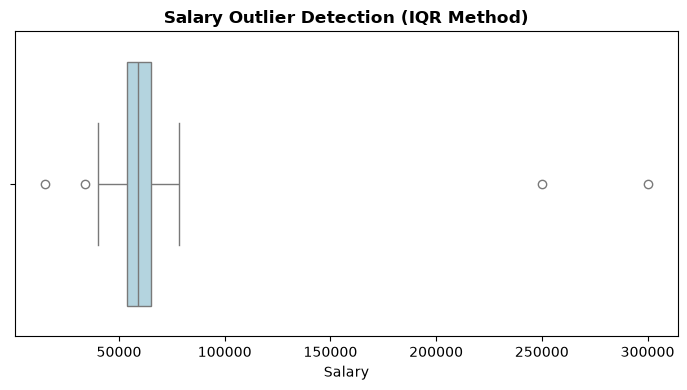

In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

output_dir = "saved_charts"
os.makedirs(output_dir, exist_ok=True)

# Generate sample data with extreme outliers
np.random.seed(42)
salaries = np.random.normal(60000, 10000, 100)
outliers = [250000, 300000, 15000]
df = pd.DataFrame({"Salary": np.concatenate([salaries, outliers])})

# Calculate IQR bounds
Q1 = df["Salary"].quantile(0.25)
Q3 = df["Salary"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

detected_outliers = df[(df["Salary"] < lower_bound) | (df["Salary"] > upper_bound)]

print(f"Q1: ${Q1:,.2f} | Q3: ${Q3:,.2f} | IQR: ${IQR:,.2f}")
print(f"Lower Bound: ${lower_bound:,.2f} | Upper Bound: ${upper_bound:,.2f}")
print(f"\nDetected {len(detected_outliers)} Outliers:")
print(detected_outliers)

# Visualize with Box Plot
plt.figure(figsize=(7, 4))
sns.boxplot(x=df["Salary"], color="lightblue")
plt.title("Salary Outlier Detection (IQR Method)", fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "Day4_SalaryOutliers.png"), dpi=300, bbox_inches="tight")
plt.show()